In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/checkpoint0-6779/Sen1Floods11_epoch394_iou0.677964_f10.717896.pt
/kaggle/input/jrcwaterhand/JRCWaterHand/Ghana_359826_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Mekong_1111068_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Spain_7558720_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Ghana_5079_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Sri-Lanka_132922_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Sri-Lanka_1038087_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/USA_605492_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Paraguay_80102_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Paraguay_149787_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Ghana_495107_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Nigeria_439488_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Ghana_362274_JRCWaterHand.tif
/kaggle/input/jrcwaterhand/JRCWaterHand/Ghana_132163_JRCWaterHand.

In [2]:
!pip install rasterio
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 55.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━

In [3]:
LR = 5e-4
EPOCHS = 1000
EPOCHS_PER_UPDATE = 1
RUNNAME = "Sen1Floods11"

In [4]:
import torch
from torchvision import transforms
import random
from PIL import Image

class InMemoryDataset(torch.utils.data.Dataset):
  def __init__(self, data_list, preprocess_func):
    self.data_list = data_list
    self.preprocess_func = preprocess_func

  def __getitem__(self, i):
    return self.preprocess_func(self.data_list[i])

  def __len__(self):
    return len(self.data_list)


import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

def processAndAugment(data):
    # CHANGED: now expects (x, labelhand, jrc)
    (x, y_total_np, y_jrc_np) = data
    im_np = x.copy()
    label_total_np = y_total_np.copy()
    label_jrc_np = y_jrc_np.copy()

    # --- Convert to torch tensors (float32) ---
    im1 = torch.from_numpy(im_np[0]).float()
    im2 = torch.from_numpy(im_np[1]).float()

    # --- clipping + scaling (same as before) ---
    vv_min, vv_max = -18.600616455078125, -4.338556289672852
    vh_min, vh_max = -26.719135284423828, -10.748163223266602

    im1 = torch.clamp(im1, vv_min, vv_max)
    im2 = torch.clamp(im2, vh_min, vh_max)
    im1 = (im1 - vv_min) / (vv_max - vv_min + 1e-6)
    im2 = (im2 - vh_min) / (vh_max - vh_min + 1e-6)

    # --- labels ---
    # LabelHand: {-1,0,1} (float)
    label_total = torch.from_numpy(label_total_np.squeeze()).float()

    # JRCWaterHand: {0,1} uint8, single band
    label_jrc = torch.from_numpy(label_jrc_np.squeeze()).float()

    H, W = im1.shape

    # --- Random Crop params (256x256) ---
    crop_h, crop_w = 256, 256
    if H < crop_h or W < crop_w:
        pad_h = max(0, crop_h - H)
        pad_w = max(0, crop_w - W)
        im1 = torch.nn.functional.pad(im1, (0, pad_w, 0, pad_h), value=0.0)
        im2 = torch.nn.functional.pad(im2, (0, pad_w, 0, pad_h), value=0.0)

        # keep ignore regions as -1 for LabelHand
        label_total = torch.nn.functional.pad(label_total, (0, pad_w, 0, pad_h), value=-1.0)

        # JRC has no -1 in your files; pad with 0 (not permanent water)
        label_jrc = torch.nn.functional.pad(label_jrc, (0, pad_w, 0, pad_h), value=0.0)
        H, W = im1.shape

    top = random.randint(0, H - crop_h)
    left = random.randint(0, W - crop_w)

    im1 = im1[top:top + crop_h, left:left + crop_w]
    im2 = im2[top:top + crop_h, left:left + crop_w]
    label_total = label_total[top:top + crop_h, left:left + crop_w]
    label_jrc = label_jrc[top:top + crop_h, left:left + crop_w]

    # --- Random flips ---
    if random.random() > 0.5:
        im1 = torch.flip(im1, dims=[1])
        im2 = torch.flip(im2, dims=[1])
        label_total = torch.flip(label_total, dims=[1])
        label_jrc = torch.flip(label_jrc, dims=[1])
    if random.random() > 0.5:
        im1 = torch.flip(im1, dims=[0])
        im2 = torch.flip(im2, dims=[0])
        label_total = torch.flip(label_total, dims=[0])
        label_jrc = torch.flip(label_jrc, dims=[0])

    # --- Random rotation ---
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        im1 = TF.rotate(im1.unsqueeze(0), angle, interpolation=InterpolationMode.BILINEAR, fill=0.0).squeeze(0)
        im2 = TF.rotate(im2.unsqueeze(0), angle, interpolation=InterpolationMode.BILINEAR, fill=0.0).squeeze(0)

        # masks: nearest; LabelHand fill=-1 to preserve ignore [web:46]
        label_total = TF.rotate(label_total.unsqueeze(0), angle, interpolation=InterpolationMode.NEAREST, fill=-1.0).squeeze(0)
        label_jrc   = TF.rotate(label_jrc.unsqueeze(0),   angle, interpolation=InterpolationMode.NEAREST, fill=0.0).squeeze(0)

    # --- Brightness / contrast (unchanged) ---
    if random.random() > 0.5:
        factor_b = random.uniform(0.9, 1.1)
        im1 = im1 * factor_b
        im2 = im2 * factor_b
    if random.random() > 0.5:
        factor_c = random.uniform(0.9, 1.1)
        mean1 = im1.mean()
        mean2 = im2.mean()
        im1 = (im1 - mean1) * factor_c + mean1
        im2 = (im2 - mean2) * factor_c + mean2

    # --- Noise (unchanged) ---
    if random.random() > 0.5:
        noise1 = torch.randn_like(im1) * 0.02
        noise2 = torch.randn_like(im2) * 0.02
        im1 = torch.clamp(im1 + noise1, 0.0, 1.0)
        im2 = torch.clamp(im2 + noise2, 0.0, 1.0)

    # --- Stack and normalize (unchanged) ---
    im = torch.stack([im1, im2], dim=0)
    norm = torch.tensor([0.6851, 0.5235], dtype=torch.float32).view(2,1,1)
    std  = torch.tensor([0.0820, 0.1102], dtype=torch.float32).view(2,1,1)
    im = (im - norm) / std

    # --- Build 3-class target ---
    # label_total in {-1,0,1}; label_jrc in {0,1}
    label_total = label_total.round()
    label_jrc = label_jrc.round()

    ignore = (label_total == -1)
    total_water = (label_total == 1)
    perm_water = (label_jrc == 1)

    # classes: 0 background, 1 perm, 2 flood
    target = torch.zeros_like(label_total, dtype=torch.long)
    target[total_water & perm_water] = 1
    target[total_water & (~perm_water)] = 2
    target[ignore] = -1  # ignore_index

    return im, target




import torch
import numpy as np
from torchvision import transforms

def processTestIm(data):
  # CHANGED: now expects (x, labelhand, jrc)
  (x, y_total_np, y_jrc_np) = data
  im_np = x.copy()
  label_total_np = y_total_np.copy()
  label_jrc_np = y_jrc_np.copy()

  norm = transforms.Normalize([0.6851, 0.5235], [0.0820, 0.1102])

  # --- inputs (stay in torch) ---
  im1 = torch.from_numpy(im_np[0]).float()   # VV (dB)
  im2 = torch.from_numpy(im_np[1]).float()   # VH (dB)

  # --- labels ---
  label_total = torch.from_numpy(np.squeeze(label_total_np)).float()  # {-1,0,1}
  label_jrc   = torch.from_numpy(np.squeeze(label_jrc_np)).float()    # {0,1}

  # --- clip+scale (same as train) ---
  vv_min, vv_max = -18.600616455078125, -4.338556289672852
  vh_min, vh_max = -26.719135284423828, -10.748163223266602

  im1 = torch.clamp(im1, vv_min, vv_max)
  im2 = torch.clamp(im2, vh_min, vh_max)
  im1 = (im1 - vv_min) / (vv_max - vv_min + 1e-6)   # -> [0,1]
  im2 = (im2 - vh_min) / (vh_max - vh_min + 1e-6)   # -> [0,1]

  # --- split into 4 crops (512 -> four 256 tiles), same as before ---
  im_c1s = [im1[0:256, 0:256], im1[0:256, 256:512],
            im1[256:512, 0:256], im1[256:512, 256:512]]
  im_c2s = [im2[0:256, 0:256], im2[0:256, 256:512],
            im2[256:512, 0:256], im2[256:512, 256:512]]

  lt = [label_total[0:256, 0:256], label_total[0:256, 256:512],
        label_total[256:512, 0:256], label_total[256:512, 256:512]]
  lj = [label_jrc[0:256, 0:256], label_jrc[0:256, 256:512],
        label_jrc[256:512, 0:256], label_jrc[256:512, 256:512]]

  # --- build image batch ---
  ims = [torch.stack((a, b)) for (a, b) in zip(im_c1s, im_c2s)]
  ims = [norm(t) for t in ims]
  ims = torch.stack(ims)  # (4,2,256,256)

  # --- build 3-class targets per tile ---
  targets = []
  for l_total, l_jrc in zip(lt, lj):
    l_total = l_total.round()
    l_jrc = l_jrc.round()

    ignore = (l_total == -1)
    total_water = (l_total == 1)
    perm_water = (l_jrc == 1)

    t = torch.zeros_like(l_total, dtype=torch.long)     # 0 background
    t[total_water & perm_water] = 1                     # 1 permanent water
    t[total_water & (~perm_water)] = 2                  # 2 flood water
    t[ignore] = -1                                      # ignore_index

    targets.append(t)

  targets = torch.stack(targets)  # (4,256,256)

  return ims, targets


In [5]:
import csv, os
import numpy as np
import rasterio

S1_ROOT   = "/kaggle/input/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/S1Hand"
LAB_ROOT  = "/kaggle/input/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand"
JRC_ROOT  = "/kaggle/input/jrcwaterhand/JRCWaterHand"

def getArrFlood(fname):
    with rasterio.open(fname) as src:
        return src.read()  # (bands,H,W)

def getArrJRC(fname):
    with rasterio.open(fname) as src:
        arr = src.read(1)  # (H,W)
    return arr[None, ...]

def download_flood_water_data_from_list(l, s1_root=S1_ROOT, lab_root=LAB_ROOT, jrc_root=JRC_ROOT, verbose_every=100):
    flood_data = []
    for k, (im_fname, mask_fname) in enumerate(l):
        s1_path  = os.path.join(s1_root, im_fname)
        lab_path = os.path.join(lab_root, mask_fname)

        if not os.path.exists(s1_path) or not os.path.exists(lab_path):
            continue

        jrc_fname = os.path.basename(mask_fname).replace("LabelHand", "JRCWaterHand")
        jrc_path  = os.path.join(jrc_root, jrc_fname)

        if (k % verbose_every) == 0:
            print("JRC_ROOT runtime =", jrc_root)
            print("mask_fname =", mask_fname)
            print("jrc_fname  =", jrc_fname)
            print("jrc_path   =", jrc_path)

        if not os.path.exists(jrc_path):
            print("Missing JRC:", jrc_path)
            continue

        arr_x = np.nan_to_num(getArrFlood(s1_path)).astype(np.float32)   # (2,H,W)
        arr_y = getArrFlood(lab_path).astype(np.float32)                 # (1,H,W) {-1,0,1}
        arr_j = getArrJRC(jrc_path).astype(np.uint8)                     # (1,H,W) {0,1}

        flood_data.append((arr_x, arr_y, arr_j))

    return flood_data

def load_flood_train_data(input_root="", label_root=""):
    csv_path = "/kaggle/input/sen1floods11-essentials/v1.2/splits/flood_handlabeled/flood_train_data.csv"
    pairs = []
    with open(csv_path) as f:
        for row in csv.reader(f):
            pairs.append((input_root + row[0], label_root + row[1]))
    return download_flood_water_data_from_list(pairs)

def load_flood_valid_data(input_root="", label_root=""):
    csv_path = "/kaggle/input/sen1floods11-essentials/v1.2/splits/flood_handlabeled/flood_val_data.csv"
    pairs = []
    with open(csv_path) as f:
        for row in csv.reader(f):
            pairs.append((input_root + row[0], label_root + row[1]))
    return download_flood_water_data_from_list(pairs)

def load_flood_test_data(input_root="", label_root=""):
    csv_path = "/kaggle/input/sen1floods11-essentials/v1.2/splits/flood_handlabeled/flood_test_data.csv"
    pairs = []
    with open(csv_path) as f:
        for row in csv.reader(f):
            pairs.append((input_root + row[0], label_root + row[1]))
    return download_flood_water_data_from_list(pairs)


In [6]:
input_root = "/kaggle/input/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/S1Hand/"
label_root = "/kaggle/input/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand/"
train_data = load_flood_train_data(input_root,label_root)
train_dataset = InMemoryDataset(train_data, processAndAugment)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, sampler=None,
                  batch_sampler=None, num_workers=0, collate_fn=None,
                  pin_memory=True, drop_last=True, timeout=0,
                  worker_init_fn=None)
train_iter = iter(train_loader)

valid_data = load_flood_valid_data(input_root, label_root)
valid_dataset = InMemoryDataset(valid_data, processTestIm)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=8, shuffle=False, sampler=None,
                  batch_sampler=None, num_workers=0, collate_fn=lambda x: (torch.cat([a[0] for a in x], 0), torch.cat([a[1] for a in x], 0)),
                  pin_memory=True, drop_last=False, timeout=0,
                  worker_init_fn=None)
valid_iter = iter(valid_loader)

test_data = load_flood_test_data(input_root,label_root)
test_dataset = InMemoryDataset(test_data, processTestIm)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False, sampler=None,
                  batch_sampler=None, num_workers=0, collate_fn=lambda x: (torch.cat([a[0] for a in x], 0), torch.cat([a[1] for a in x], 0)),
                  pin_memory=True, drop_last=False, timeout=0,
                  worker_init_fn=None)

test_iter = iter(test_loader)


/tmp/ipykernel_40/1683649418.py:11: RuntimeWarning: invalid value encountered in greater
  return src.read()  # (bands,H,W)
/tmp/ipykernel_40/1683649418.py:11: RuntimeWarning: invalid value encountered in less
  return src.read()  # (bands,H,W)


JRC_ROOT runtime = /kaggle/input/jrcwaterhand/JRCWaterHand
mask_fname = /kaggle/input/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand/Pakistan_909806_LabelHand.tif
jrc_fname  = Pakistan_909806_JRCWaterHand.tif
jrc_path   = /kaggle/input/jrcwaterhand/JRCWaterHand/Pakistan_909806_JRCWaterHand.tif
JRC_ROOT runtime = /kaggle/input/jrcwaterhand/JRCWaterHand
mask_fname = /kaggle/input/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand/Sri-Lanka_579082_LabelHand.tif
jrc_fname  = Sri-Lanka_579082_JRCWaterHand.tif
jrc_path   = /kaggle/input/jrcwaterhand/JRCWaterHand/Sri-Lanka_579082_JRCWaterHand.tif


In [7]:
print("Train data length:", len(train_data))
print("Valid data length:", len(valid_data))
print("Test data length:", len(test_data))

Train data length: 252
Valid data length: 89
Test data length: 89


In [8]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss, FocalLoss

# -------------------------------------------------------
# Model: UNet++ with EfficientNet-B4 (stronger encoder)
# -------------------------------------------------------
net = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4",  # Better generalization than resnet34 [web:1139]
    encoder_weights="imagenet",
    in_channels=2,     
    classes=3,          # 0=bg, 1=perm, 2=flood
)

# -------------------------------------------------------
# Loss: Focal + Dice (Best combo for imbalance)
# -------------------------------------------------------
class FocalDiceLoss(nn.Module):
    def __init__(self, ignore_index=-1, dice_w=0.5, focal_w=0.5):
        super().__init__()
        # Focal Loss handles class imbalance better than weighted CE
        self.focal = FocalLoss(
            mode="multiclass",
            ignore_index=ignore_index,
            normalized=True
        )
        self.dice = DiceLoss(
            mode="multiclass",
            from_logits=True,
            ignore_index=ignore_index,
            smooth=1e-6
        )
        self.dice_w = dice_w
        self.focal_w = focal_w

    def forward(self, y_pred, y_true):
        return self.focal_w * self.focal(y_pred, y_true) + \
               self.dice_w * self.dice(y_pred, y_true)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-initialize criterion with new loss
criterion = FocalDiceLoss(ignore_index=-1).to(device)

# -------------------------------------------------------
# Optimizer & Scheduler
# -------------------------------------------------------
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-4) # Lower start LR for efficientnet

# ReduceLROnPlateau is often better for segmentation than Cosine [web:1139]
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

# -------------------------------------------------------
# Helper: Convert BN -> GN (Keep this if batch_size is small, e.g. < 16)
# -------------------------------------------------------
def convertBNtoGN(module, num_groups=16):
    if isinstance(module, nn.BatchNorm2d):
        # EfficientNet uses many channels; ensure groups divide channels
        num_channels = module.num_features
        # Safe group selection: usually 16 or 32, but must divide channels
        groups = num_groups if num_channels % num_groups == 0 else 1
        
        gn = nn.GroupNorm(groups, num_channels, eps=module.eps, affine=module.affine)
        if module.affine:
            with torch.no_grad():
                gn.weight.data = module.weight.data.clone().detach()
                gn.bias.data = module.bias.data.clone().detach()
        return gn

    for name, child in list(module.named_children()):
        new_child = convertBNtoGN(child, num_groups=num_groups)
        module.add_module(name, new_child)
    return module

# Apply GN if needed (EfficientNet usually needs batch_size >= 8-16 for BN to work well)
# If batch_size < 8, uncomment the line below:
# net = convertBNtoGN(net).to(device)
net = net.to(device)


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [9]:
import torch
import segmentation_models_pytorch as smp

# Setup: classes {0:bg, 1:perm, 2:flood}, ignore = -1
NUM_CLASSES = 3
IGNORE_INDEX = -1

@torch.no_grad()
def _mask_ignore(output_logits, target):
    """
    output_logits: (N,C,H,W) float logits
    target: (N,H,W) long with values in {-1,0,1,2}
    returns:
      pred_valid, tgt_valid: flattened 1D long tensors with ignore removed
    """
    pred = torch.argmax(output_logits, dim=1)  # (N,H,W) [web:649]
    tgt = target

    valid = tgt.ne(IGNORE_INDEX)               # ignore mask [web:591]
    pred_valid = pred[valid].long()
    tgt_valid  = tgt[valid].long()
    return pred_valid, tgt_valid


@torch.no_grad()
def computeIOU(output, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX, drop_bg=True):
    """
    Returns macro IoU (mean over classes).
    If drop_bg=True, averages only classes 1..C-1.
    """
    pred = torch.argmax(output, dim=1)  # (N,H,W) [web:649]

    tp, fp, fn, tn = smp.metrics.get_stats(
        pred, target,
        mode="multiclass",
        num_classes=num_classes,
        ignore_index=ignore_index
    )  # [web:591]

    iou_per_class = smp.metrics.iou_score(tp, fp, fn, tn, reduction=None)  # (C,) [web:597]
    iou = iou_per_class[1:].mean() if drop_bg else iou_per_class.mean()

    # keep NaN guard (can happen if a class is absent everywhere)
    if torch.isnan(iou):
        print("failed, replacing with 0")
        iou = torch.tensor(0.0, device=output.device)

    return iou


@torch.no_grad()
def computeF1(output, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX, drop_bg=True):
    """
    Returns macro F1 (mean over classes).
    If drop_bg=True, averages only classes 1..C-1.
    """
    pred = torch.argmax(output, dim=1)  # (N,H,W) [web:649]

    tp, fp, fn, tn = smp.metrics.get_stats(
        pred, target,
        mode="multiclass",
        num_classes=num_classes,
        ignore_index=ignore_index
    )  # [web:591]

    f1_per_class = smp.metrics.f1_score(tp, fp, fn, tn, reduction=None)  # (C,) [web:597]
    f1 = f1_per_class[1:].mean() if drop_bg else f1_per_class.mean()

    if torch.isnan(f1):
        print("failed, replacing with 0")
        f1 = torch.tensor(0.0, device=output.device)

    return f1


@torch.no_grad()
def computeAccuracy(output, target):
    """
    Pixel accuracy excluding ignore_index.
    """
    pred_valid, tgt_valid = _mask_ignore(output, target)
    if tgt_valid.numel() == 0:
        return torch.tensor(0.0, device=output.device)
    correct = (pred_valid == tgt_valid).sum()
    return correct.float() / tgt_valid.numel()


# Note: For multiclass, "TN" depends on treating "class_id vs all other classes".
@torch.no_grad()
def truePositives(output, target, class_id=1):
    pred_valid, tgt_valid = _mask_ignore(output, target)
    return ((pred_valid == class_id) & (tgt_valid == class_id)).sum()

@torch.no_grad()
def falsePositives(output, target, class_id=1):
    pred_valid, tgt_valid = _mask_ignore(output, target)
    return ((pred_valid == class_id) & (tgt_valid != class_id)).sum()

@torch.no_grad()
def falseNegatives(output, target, class_id=1):
    pred_valid, tgt_valid = _mask_ignore(output, target)
    return ((pred_valid != class_id) & (tgt_valid == class_id)).sum()

@torch.no_grad()
def trueNegatives(output, target, class_id=1):
    pred_valid, tgt_valid = _mask_ignore(output, target)
    return ((pred_valid != class_id) & (tgt_valid != class_id)).sum()


In [10]:
training_losses = []
training_accuracies = []
training_ious = []
training_f1s = []

running_loss = 0.0
running_iou = 0.0
running_accuracy = 0.0
running_f1 = 0.0
running_count = 0

def train_loop(inputs, labels, net, optimizer, scheduler, device="cuda"):
    global running_loss, running_iou, running_count, running_accuracy, running_f1

    net.train()

    inputs = inputs.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True).long()

    optimizer.zero_grad(set_to_none=True)

    outputs = net(inputs)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    # REMOVED: scheduler.step() -- Call this ONCE per epoch in train_validation_loop instead!

    with torch.no_grad():
        batch_iou = computeIOU(outputs, labels)
        batch_acc = computeAccuracy(outputs, labels)
        batch_f1  = computeF1(outputs, labels)

        running_loss += float(loss.item())
        running_iou += float(batch_iou.item())
        running_accuracy += float(batch_acc.item())
        running_f1 += float(batch_f1.item())
        running_count += 1

    return float(loss.item()), float(batch_iou.item()), float(batch_acc.item()), float(batch_f1.item())




In [11]:
import os
import torch

# ---- define these ONCE before training starts ----
max_valid_iou = 0.0
best_f1_at_max_iou = -1.0
best_epoch_at_max_iou = -1

valid_losses = []
valid_accuracies = []
valid_ious = []
valid_f1s = []

def validation_loop(validation_data_loader, net, epoch, device="cuda"):
    global running_loss, running_iou, running_count, running_accuracy, running_f1
    global max_valid_iou, best_f1_at_max_iou, best_epoch_at_max_iou
    global training_losses, training_accuracies, training_ious, training_f1s
    global valid_losses, valid_accuracies, valid_ious, valid_f1s

    net.eval()                           # eval mode [web:669]
    net = net.to(device)

    total_iou = 0.0
    total_f1 = 0.0
    total_loss = 0.0
    total_acc = 0.0
    count = 0

    with torch.no_grad():
        for images, labels in validation_data_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).long()  # CE needs long targets [web:550][web:611]

            outputs = net(images)  # logits [B,C,H,W]

            v_loss = criterion(outputs, labels)  # should use ignore_index=-1 [web:657][web:550]
            v_iou  = computeIOU(outputs, labels)
            v_f1   = computeF1(outputs, labels)
            v_acc  = computeAccuracy(outputs, labels)

            total_loss += float(v_loss.item())
            total_iou  += float(v_iou.item())
            total_f1   += float(v_f1.item())
            total_acc  += float(v_acc.item())
            count += 1

    avg_loss = total_loss / max(count, 1)
    avg_iou  = total_iou  / max(count, 1)
    avg_f1   = total_f1   / max(count, 1)
    avg_acc  = total_acc  / max(count, 1)

    # ---- compute epoch training averages safely ----
    if running_count > 0:
        train_loss = float(running_loss / running_count)
        train_iou  = float(running_iou / running_count)
        train_acc  = float(running_accuracy / running_count)
        train_f1   = float(running_f1 / running_count) if "running_f1" in globals() else None
    else:
        train_loss, train_iou, train_acc, train_f1 = 0.0, 0.0, 0.0, None

    # ---- Save model if validation IoU improves (IoU-based checkpoint) ----
    if avg_iou > float(max_valid_iou):
        max_valid_iou = float(avg_iou)
        best_f1_at_max_iou = float(avg_f1)
        best_epoch_at_max_iou = int(epoch)

        checkpoint_dir = "/kaggle/working/checkpoints"
        os.makedirs(checkpoint_dir, exist_ok=True)

        save_path = os.path.join(
            checkpoint_dir,
            f"{RUNNAME}_epoch{epoch}_iou{max_valid_iou:.6f}_f1{best_f1_at_max_iou:.6f}.pt"
        )

        # Save a dict so you keep the metrics with the checkpoint [web:718]
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": net.state_dict(),
                "max_valid_iou": max_valid_iou,
                "f1_at_max_iou": best_f1_at_max_iou,
            },
            save_path
        )
        print(f"New best IoU: {max_valid_iou:.6f} with F1: {best_f1_at_max_iou:.6f} (epoch {epoch})")
        print("model saved at", save_path)

    # ---- Print metrics ----
    print("Training Loss:", train_loss)
    print("Training IOU:", train_iou)
    if train_f1 is not None:
        print("Training F1:", train_f1)
    print("Training Accuracy:", train_acc)

    print("Validation Loss:", avg_loss)
    print("Validation IOU:", avg_iou)
    print("Validation F1:", avg_f1)
    print("Validation Accuracy:", avg_acc)

    print("max valid iou:", max_valid_iou)
    print("f1 at max valid iou:", best_f1_at_max_iou)
    print("epoch at max valid iou:", best_epoch_at_max_iou)

    # ---- Append floats to history ----
    training_losses.append(train_loss)
    training_accuracies.append(train_acc)
    training_ious.append(train_iou)
    if train_f1 is not None:
        training_f1s.append(train_f1)

    valid_losses.append(avg_loss)
    valid_accuracies.append(avg_acc)
    valid_ious.append(avg_iou)
    valid_f1s.append(avg_f1)

    return avg_loss, avg_iou, avg_f1, avg_acc



In [21]:
import itertools
from tqdm.notebook import tqdm
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
from sklearn.metrics import confusion_matrix

# ── Constants ─────────────────────────────────────────────────────────────
IGNORE_INDEX = -1
CLASS_NAMES  = ["Background", "Permanent Water", "Flood Water"]

# ── Colormap ──────────────────────────────────────────────────────────────
CMAP_PF = ListedColormap([
    (0.08, 0.08, 0.10, 0.0),
    (0.18, 0.55, 1.00, 0.88),
    (1.00, 0.27, 0.27, 0.88),
])
NORM_PF = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], CMAP_PF.N)

# ── Helpers ───────────────────────────────────────────────────────────────
def _to_numpy(x):
    return x.detach().cpu().numpy()

def _percentile_clip(arr, lo=1, hi=99):
    p_lo, p_hi = np.percentile(arr, [lo, hi])
    return np.clip((arr - p_lo) / max(p_hi - p_lo, 1e-8), 0, 1)

# ── Confusion matrix ──────────────────────────────────────────────────────
def plot_confusion_matrix(all_gt, all_pred):
    cm = confusion_matrix(all_gt, all_pred, labels=[0, 1, 2])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)

    for i, j in itertools.product(range(3), range(3)):
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_pct[i, j]:.1%})",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white" if cm_pct[i, j] < 0.55 else "black"
        )

    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Ground Truth")
    ax.set_title("Confusion Matrix")

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# ── Sample visualisation ──────────────────────────────────────────────────
def _plot_sample(k, vv_raw, gt, pr):
    sar = _percentile_clip(vv_raw)

    gt_disp = gt.copy()
    gt_disp[gt_disp == IGNORE_INDEX] = 0

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    plt.subplots_adjust(wspace=0.05)

    titles = ["SAR", "Ground Truth", "Prediction"]

    axes[0].imshow(sar, cmap="gray")
    axes[0].set_title(titles[0], fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(sar, cmap="gray")
    axes[1].imshow(gt_disp, cmap=CMAP_PF, norm=NORM_PF, interpolation="nearest")
    axes[1].set_title(titles[1], fontsize=11)
    axes[1].axis("off")

    axes[2].imshow(sar, cmap="gray")
    axes[2].imshow(pr, cmap=CMAP_PF, norm=NORM_PF, interpolation="nearest")
    axes[2].set_title(titles[2], fontsize=11)
    axes[2].axis("off")

    fig.suptitle(f"Sample {k + 1}", fontsize=12)

    plt.show()
    plt.close(fig)

# ── Main test loop ────────────────────────────────────────────────────────
def test_loop(test_data_loader, net, device="cuda", num_show=10):
    """
    Displays:
      1. Sample predictions
      2. Confusion matrix

    Returns:
      avg_loss, avg_iou, avg_f1, avg_acc
    """

    net.eval()
    net = net.to(device)

    total_loss = 0.0
    total_iou  = 0.0
    total_f1   = 0.0
    total_acc  = 0.0
    count = 0

    examples = []
    all_gt = []
    all_pred = []

    with torch.no_grad():
        for images, labels in tqdm(test_data_loader, desc="Testing"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).long()

            outputs = net(images)
            preds = torch.argmax(outputs, dim=1)

            total_loss += float(criterion(outputs, labels).item())
            total_iou  += float(computeIOU(outputs, labels).item())
            total_f1   += float(computeF1(outputs, labels).item())
            total_acc  += float(computeAccuracy(outputs, labels).item())
            count += 1

            gt_np = _to_numpy(labels)
            pr_np = _to_numpy(preds)

            mask = gt_np != IGNORE_INDEX
            all_gt.extend(gt_np[mask].ravel().tolist())
            all_pred.extend(pr_np[mask].ravel().tolist())

            if len(examples) < num_show:
                for bi in range(images.shape[0]):
                    if len(examples) >= num_show:
                        break
                    examples.append((
                        _to_numpy(images[bi, 0]),
                        gt_np[bi],
                        pr_np[bi],
                    ))

    n = max(count, 1)

    avg_loss = total_loss / n
    avg_iou  = total_iou / n
    avg_f1   = total_f1 / n
    avg_acc  = total_acc / n

    # sample visualisation
    for k, (vv, gt, pr) in enumerate(examples):
        _plot_sample(k, vv, gt, pr)

    # confusion matrix
    plot_confusion_matrix(np.array(all_gt), np.array(all_pred))

    return avg_loss, avg_iou, avg_f1, avg_acc

In [19]:
from tqdm.notebook import tqdm
from IPython.display import clear_output

# Running metrics (per epoch)
running_loss = 0.0
running_iou = 0.0
running_accuracy = 0.0
running_f1 = 0.0
running_count = 0

# History
training_losses = []
training_accuracies = []
training_ious = []
training_f1s = []

valid_losses = []
valid_accuracies = []
valid_ious = []
valid_f1s = []

def reset_running_metrics():
    global running_loss, running_iou, running_accuracy, running_f1, running_count
    running_loss = 0.0
    running_iou = 0.0
    running_accuracy = 0.0
    running_f1 = 0.0
    running_count = 0

def train_epoch(net, optimizer, scheduler, train_loader, device="cuda"):
    # net.train() is already called inside train_loop, but keeping it here is also fine
    for inputs, labels in tqdm(train_loader, leave=False):
        # train_loop returns (loss, iou, acc, f1) if you used the updated version
        train_loop(inputs, labels, net, optimizer, scheduler, device=device)

def train_validation_loop(net, optimizer, scheduler,
                          train_loader, valid_loader,
                          num_epochs, start_epoch=0,
                          device="cuda", clear_each_epoch=True):

    net = net.to(device)  # Move model once

    for epoch in range(start_epoch, start_epoch + num_epochs):
        # Reset running metrics for the new epoch (if you use global counters)
        reset_running_metrics()

        # ---- 1. Train 1 epoch ----
        train_epoch(net, optimizer, scheduler, train_loader, device=device)

        if clear_each_epoch:
            clear_output(wait=True)

        print("Current Epoch:", epoch)

        # ---- 2. Validate 1 epoch ----
        # IMPORTANT: Capture the return values so we can use them for the scheduler
        val_loss, val_iou, val_f1, val_acc = validation_loop(valid_loader, net, epoch=epoch, device=device)

        # ---- 3. Step Scheduler (ReduceLROnPlateau) ----
        if scheduler is not None:
            # Check if it's ReduceLROnPlateau (needs a metric)
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                # We want to maximize IoU, so pass val_iou.
                # (Make sure scheduler was init with mode='max' if using IoU, or 'min' if using Loss)
                scheduler.step(val_iou)
            else:
                # For other schedulers (StepLR, Cosine, etc.) that step per epoch
                scheduler.step()



In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch

# These must exist as globals and be updated inside validation_loop when IoU improves:
# max_valid_iou, best_f1_at_max_iou, best_epoch_at_max_iou
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
start = 0
num_epochs = 1000

epochs = []

# Make sure these lists exist (and include F1)
training_losses = []
training_accuracies = []
training_ious = []
training_f1s = []

valid_losses = []
valid_accuracies = []
valid_ious = []
valid_f1s = []

for epoch in range(start, num_epochs):
    # IMPORTANT: run exactly 1 epoch each iteration
    train_validation_loop(
        net, optimizer, scheduler,
        train_loader, valid_loader,
        num_epochs=1,
        start_epoch=epoch,
        device=DEVICE,
        clear_each_epoch=False
    )

    # If anything accidentally appended tensors, force-convert the last items to float
    def _fix_last(lst):
        if len(lst) > 0 and torch.is_tensor(lst[-1]):
            lst[-1] = float(lst[-1].item())

    _fix_last(training_losses)
    _fix_last(training_accuracies)
    _fix_last(training_ious)
    _fix_last(training_f1s)
    _fix_last(valid_losses)
    _fix_last(valid_accuracies)
    _fix_last(valid_ious)
    _fix_last(valid_f1s)

    epochs.append(epoch)

    clear_output(wait=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # subplots [web:810]

    # ---- Loss (left) ----
    ax1.plot(epochs, training_losses, label="Training Loss", color="blue")
    ax1.plot(epochs, valid_losses, label="Validation Loss", color="cyan")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss")
    ax1.grid(True)
    ax1.legend()

    # ---- Metrics (right) ----
    ax2.plot(epochs, training_accuracies, label="Training Accuracy", color="orange")
    ax2.plot(epochs, training_ious, label="Training IoU", color="purple")
    ax2.plot(epochs, training_f1s, label="Training F1", color="brown")

    ax2.plot(epochs, valid_accuracies, label="Validation Accuracy", color="red")
    ax2.plot(epochs, valid_ious, label="Validation IoU", color="green")
    ax2.plot(epochs, valid_f1s, label="Validation F1", color="black")

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Score")
    ax2.set_title("IoU / F1 / Accuracy")
    ax2.grid(True)
    ax2.legend(loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

    print("max valid iou:", max_valid_iou)
    print("f1 at max valid iou:", best_f1_at_max_iou)
    print("epoch at max valid iou:", best_epoch_at_max_iou)


Loaded checkpoint: /kaggle/input/checkpoint0-6779/Sen1Floods11_epoch394_iou0.677964_f10.717896.pt
Checkpoint epoch: 394
Checkpoint max_valid_iou: 0.6779635200897852
Checkpoint f1_at_max_iou: 0.717895895242691


Testing:   0%|          | 0/12 [00:00<?, ?it/s]

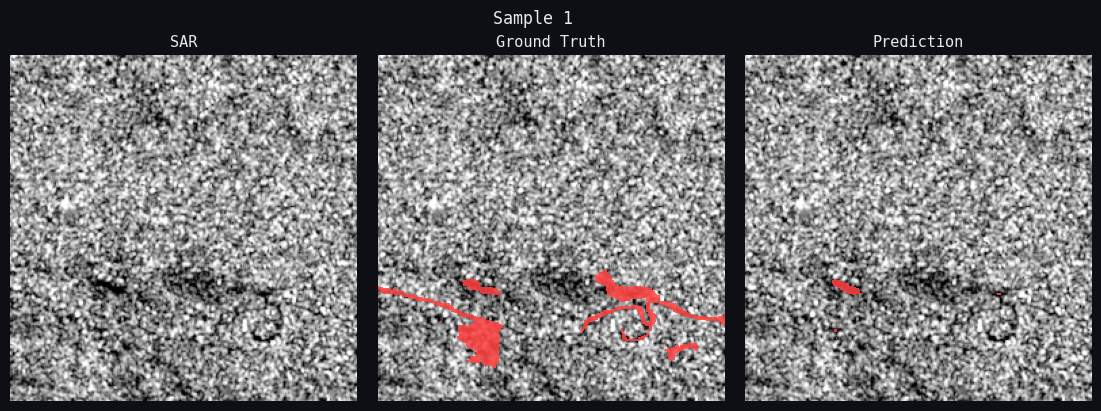

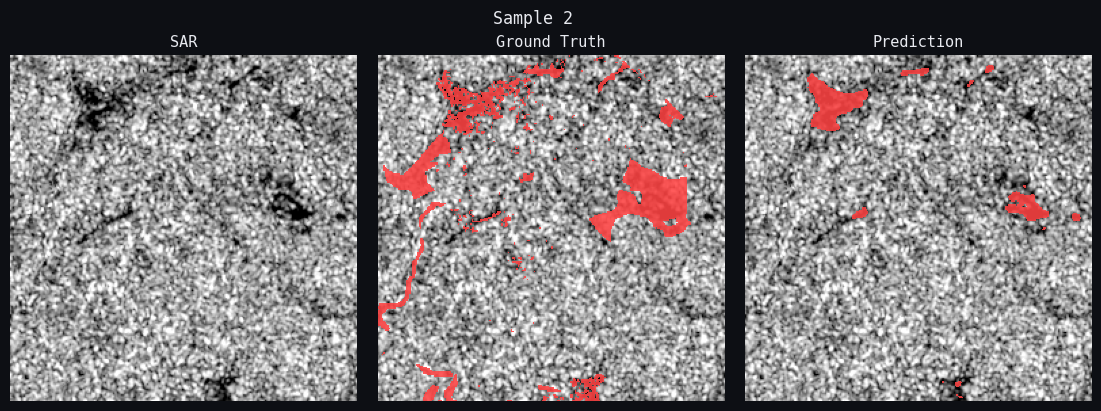

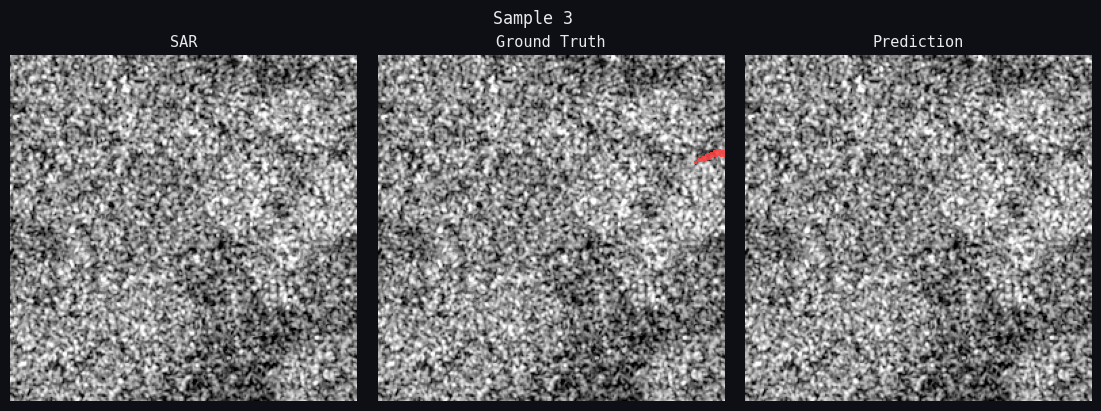

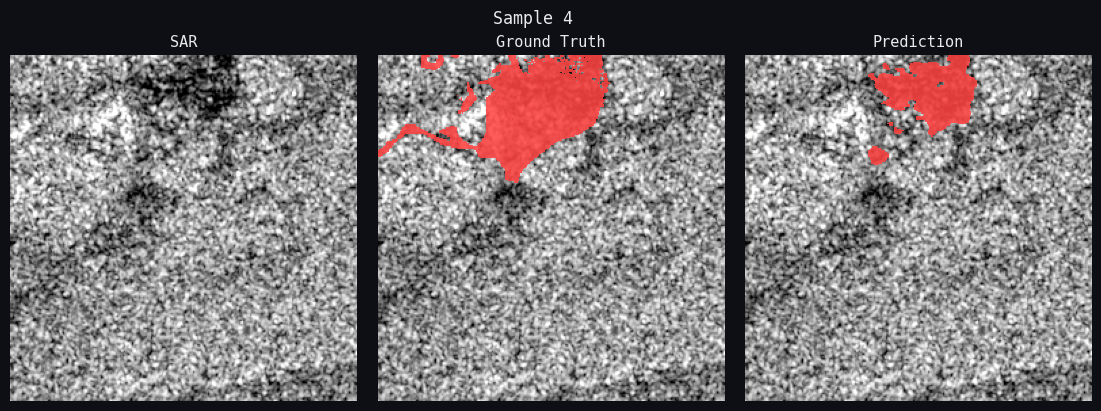

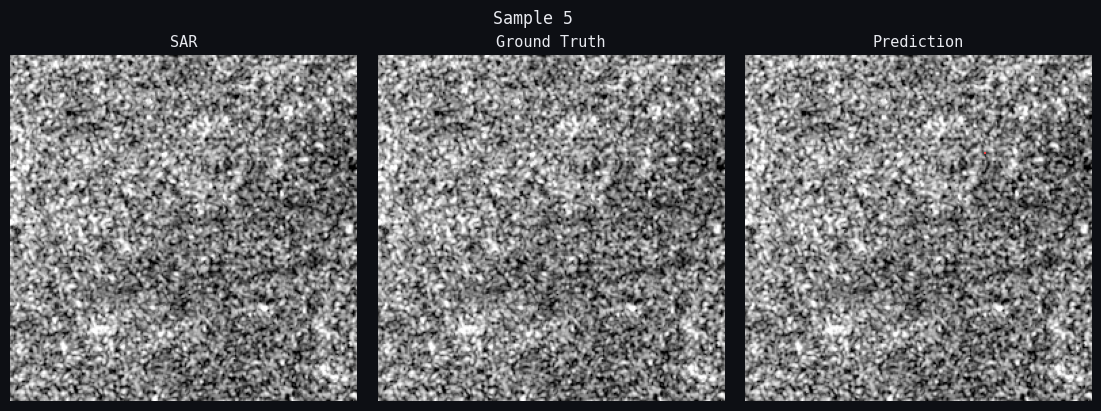

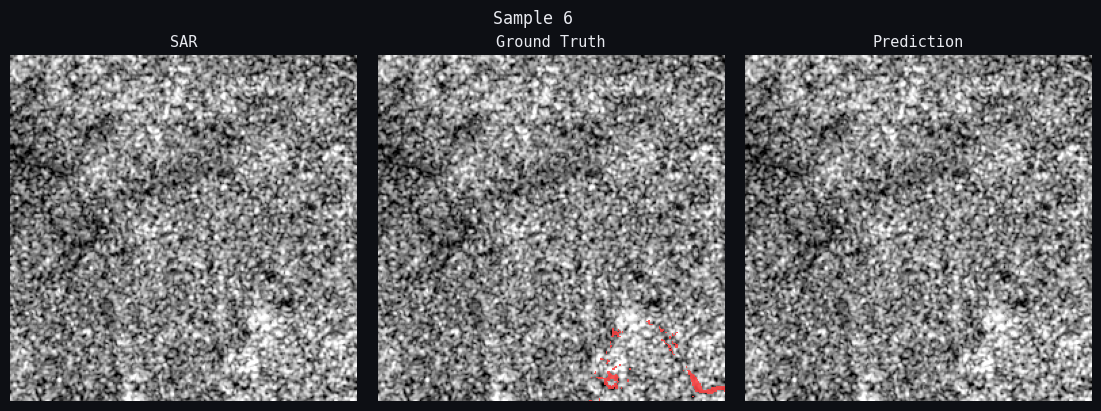

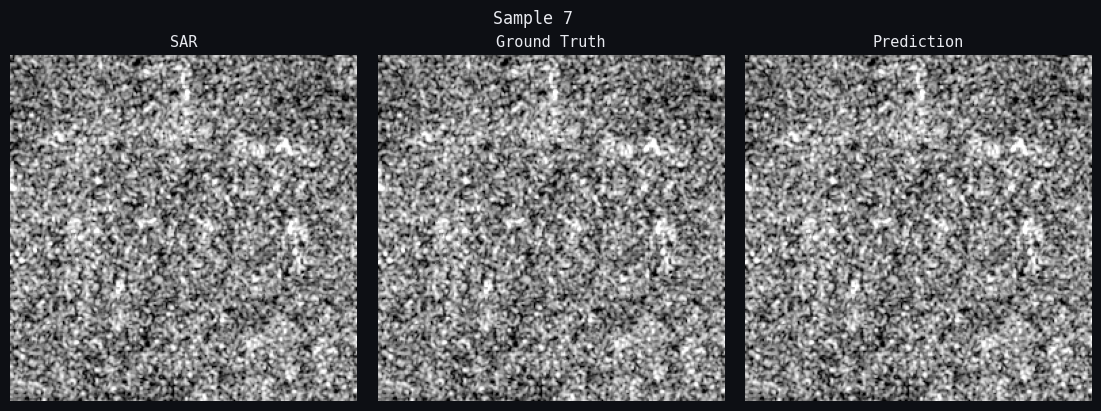

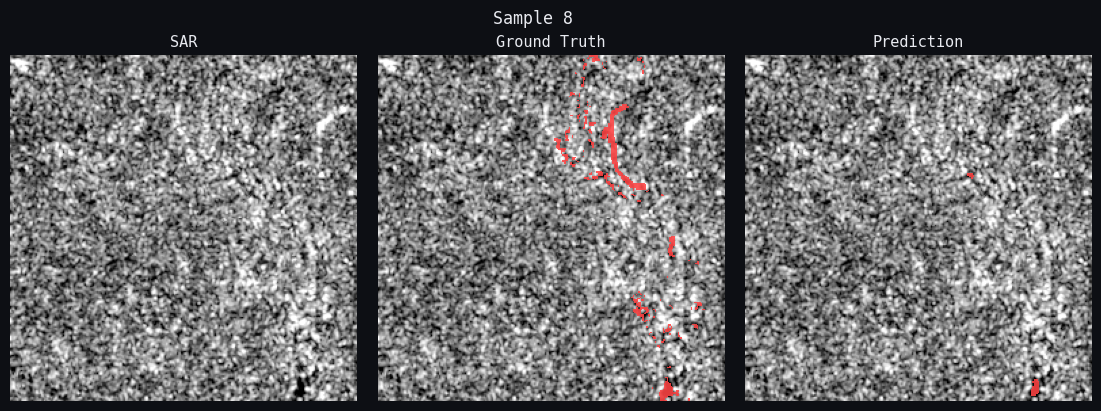

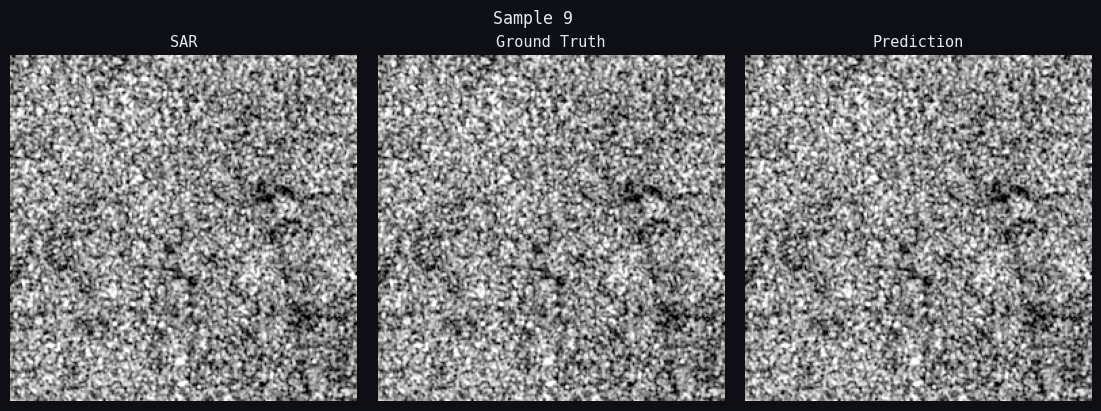

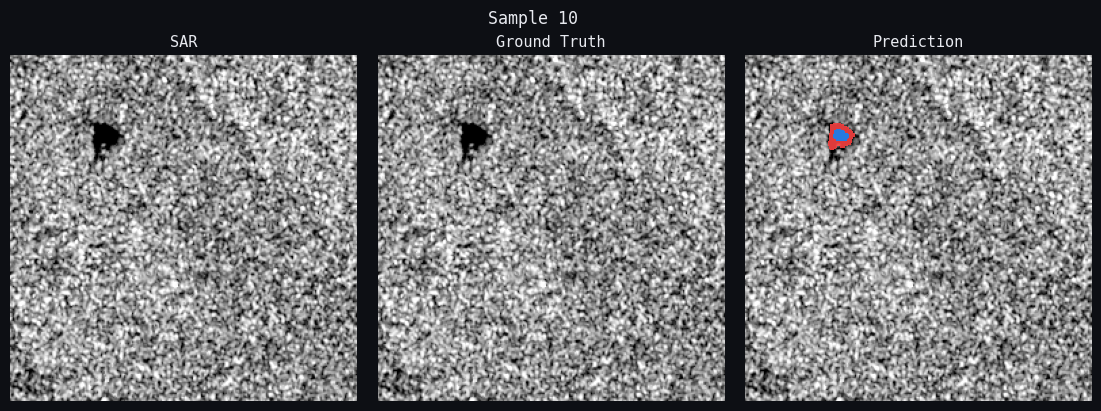

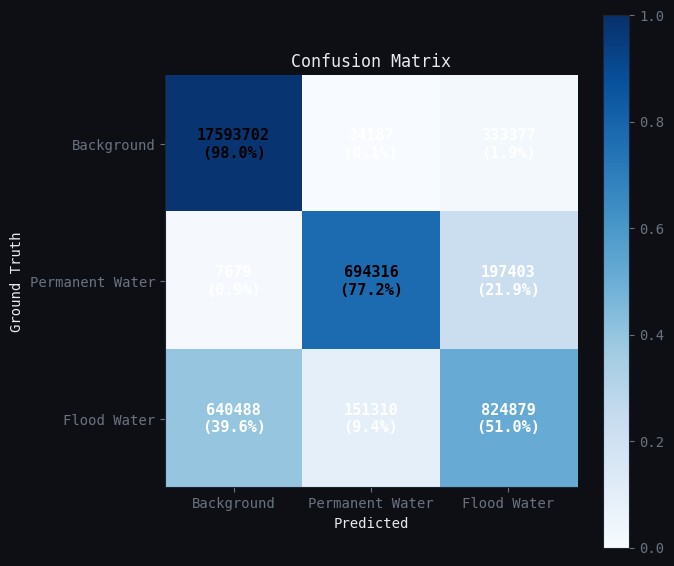

0.14406668270627657 0.6671033253272375 0.7110596845547358 0.93580694993337


In [23]:
checkpoint_path = "/kaggle/input/checkpoint0-6779/Sen1Floods11_epoch394_iou0.677964_f10.717896.pt"

ckpt = torch.load(checkpoint_path, map_location="cpu")  # safer [web:1031]

# If you saved a dict (recommended), weights are inside "model_state_dict" [web:718]
state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt

net.load_state_dict(state_dict, strict=True)
net = net.to("cuda").eval()

print("Loaded checkpoint:", checkpoint_path)
if isinstance(ckpt, dict):
    print("Checkpoint epoch:", ckpt.get("epoch"))
    print("Checkpoint max_valid_iou:", ckpt.get("max_valid_iou"))
    print("Checkpoint f1_at_max_iou:", ckpt.get("f1_at_max_iou"))


#test_loop(test_loader, net)
avg_loss, avg_iou, avg_f1, avg_acc = test_loop(
    test_loader,
    net,
    device="cuda",
    num_show=10
)

print(avg_loss, avg_iou, avg_f1, avg_acc)


Visualizing JRCWaterHand

In [ ]:
import rasterio

path = "/kaggle/input/jrcwaterhand/JRCWaterHand/Bolivia_103757_JRCWaterHand.tif"

with rasterio.open(path) as src:
    print("count:", src.count)
    print("width,height:", src.width, src.height)
    print("dtype:", src.dtypes)

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

path = "/kaggle/input/jrcwaterhand/JRCWaterHand/Bolivia_129334_JRCWaterHand.tif"

with rasterio.open(path) as src:
    m = src.read(1)

print("dtype:", m.dtype, "shape:", m.shape)
print("min/max:", int(m.min()), int(m.max()))
vals, counts = np.unique(m, return_counts=True)
print("unique values + counts:", list(zip(vals.tolist(), counts.tolist()))[:20])

plt.figure(figsize=(5,5))
plt.imshow(m, cmap="gray", vmin=m.min(), vmax=m.max())  # force correct contrast scaling
plt.title("Raw mask (auto-scaled)")
plt.axis("off")
plt.show()


Valid train tiles: 252


Scanning labels: 100%|██████████| 252/252 [00:01<00:00, 150.76it/s]



────────────────────────────────────────────────────────
Class                          Pixels  % of valid
────────────────────────────────────────────────────────
Background                 51,856,372     90.494%
Permanent Water             1,521,824      2.656%
Flood Water                 3,925,211      6.850%
────────────────────────────────────────────────────────
Ignored / no-data           8,756,881
Total pixels               66,060,288
────────────────────────────────────────────────────────

Suggested class weights (inverse-frequency, normalised):
  Background             0.020710
  Permanent Water        0.705690
  Flood Water            0.273600

Paste into training script:
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor([0.02071, 0.70569, 0.2736], dtype=torch.float).to(device),
        ignore_index=-1,
    )


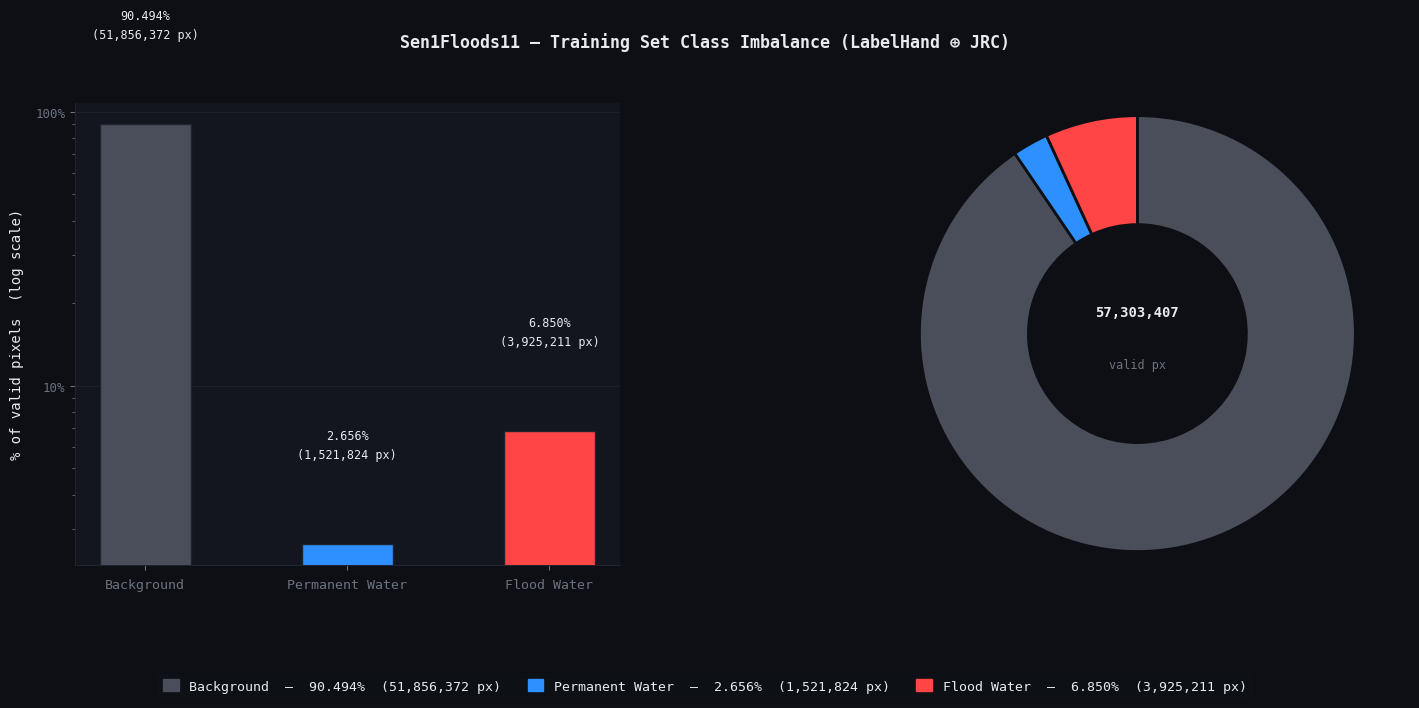


✓ Saved → class_imbalance.png


In [29]:
"""
Class Imbalance Analysis — Sen1Floods11 (train split only)
==========================================================
Replicates the exact 3-class label logic from processAndAugment:
  - LabelHand  {-1, 0, 1}  : total water mask (hand-labeled)
  - JRCWaterHand {0, 1}    : permanent water (JRC Global Surface Water)

  Derived classes
  ---------------
  0  background        : label_total == 0
  1  permanent water   : label_total == 1  AND  label_jrc == 1
  2  flood water       : label_total == 1  AND  label_jrc == 0
  -1 ignore            : label_total == -1
"""

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm

# ── Config ─────────────────────────────────────────────────────────────────────
CSV_PATH     = "/kaggle/input/sen1floods11-essentials/v1.2/splits/flood_handlabeled/flood_train_data.csv"
LABEL_HAND_DIR = Path("/kaggle/input/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand")
JRC_DIR        = Path("/kaggle/input/jrcwaterhand/JRCWaterHand")

IGNORE_VAL  = -1
CLASS_NAMES = ["Background", "Permanent Water", "Flood Water"]

# ── Style ──────────────────────────────────────────────────────────────────────
BG, PANEL, BORDER = "#0d0f14", "#13161e", "#1e2330"
TEXT, MUTED = "#e8eaf0", "#6b7280"
COLORS = ["#4a4e5a", "#2e8fff", "#ff4545"]

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL,
    "axes.edgecolor": BORDER, "text.color": TEXT,
    "axes.labelcolor": TEXT, "xtick.color": MUTED,
    "ytick.color": MUTED, "font.family": "monospace",
    "axes.spines.top": False, "axes.spines.right": False,
})

# ── 1. Parse CSV ───────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, header=None, names=["s1", "label"])
df = df[df["label"].str.endswith(".tif")].reset_index(drop=True)
print(f"Valid train tiles: {len(df)}")

# ── 2. Count pixels using the exact same label fusion logic ───────────────────
counts     = {0: 0, 1: 0, 2: 0}
ignored_px = 0
missing    = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Scanning labels"):
    hand_file = LABEL_HAND_DIR / row["label"].strip()

    # JRC filename: replace "LabelHand" suffix with "JRCWaterHand"
    jrc_fname = row["label"].strip().replace("LabelHand", "JRCWaterHand")
    jrc_file  = JRC_DIR / jrc_fname

    if not hand_file.exists():
        missing.append(f"HAND missing: {hand_file}")
        continue
    if not jrc_file.exists():
        missing.append(f"JRC  missing: {jrc_file}")
        continue

    with rasterio.open(hand_file) as src:
        label_hand = src.read(1).astype(np.int16)   # {-1, 0, 1}
    with rasterio.open(jrc_file) as src:
        label_jrc  = src.read(1).astype(np.uint8)   # {0, 1}

    ignore      = (label_hand == -1)
    total_water = (label_hand == 1)
    perm_water  = (label_jrc  == 1)

    ignored_px      += int(ignore.sum())
    counts[0]       += int((~ignore & ~total_water).sum())          # background
    counts[1]       += int((total_water &  perm_water).sum())       # permanent
    counts[2]       += int((total_water & ~perm_water).sum())       # flood

if missing:
    print(f"\n⚠  {len(missing)} file(s) not found (first 5):")
    for p in missing[:5]:
        print("  ", p)

# ── 3. Statistics ──────────────────────────────────────────────────────────────
total_valid = sum(counts.values())
total_all   = total_valid + ignored_px

print("\n" + "─" * 56)
print(f"{'Class':<22} {'Pixels':>14}  {'% of valid':>10}")
print("─" * 56)
for cls, name in enumerate(CLASS_NAMES):
    pct = 100 * counts[cls] / max(total_valid, 1)
    print(f"{name:<22} {counts[cls]:>14,}  {pct:>9.3f}%")
print("─" * 56)
print(f"{'Ignored / no-data':<22} {ignored_px:>14,}")
print(f"{'Total pixels':<22} {total_all:>14,}")
print("─" * 56)

# ── 4. Class weights ───────────────────────────────────────────────────────────
freqs = np.array([counts[c] for c in range(3)], dtype=float)

if freqs.min() == 0:
    print("\n⚠  A class has 0 pixels — check JRC directory path.")
else:
    # Inverse-frequency, normalised to sum=1
    weights = total_valid / (3.0 * freqs)
    weights /= weights.sum()

    print("\nSuggested class weights (inverse-frequency, normalised):")
    for name, w in zip(CLASS_NAMES, weights):
        print(f"  {name:<22} {w:.6f}")

    w_list = weights.round(6).tolist()
    print(f"""
Paste into training script:
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor({w_list}, dtype=torch.float).to(device),
        ignore_index=-1,
    )""")

# ── 5. Visualisation ───────────────────────────────────────────────────────────
pcts = [100 * counts[c] / max(total_valid, 1) for c in range(3)]

fig = plt.figure(figsize=(15, 7), facecolor=BG)

fig.suptitle("Sen1Floods11 — Training Set Class Imbalance (LabelHand ⊕ JRC)",
             fontsize=12, fontweight="bold", color=TEXT, y=0.98)

gs = fig.add_gridspec(1, 2,
                      left=0.08, right=0.97,
                      top=0.88, bottom=0.22,   # large bottom margin for legend
                      wspace=0.45)

# ── Left: log-scale bar chart ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[0])

bars = ax.bar(CLASS_NAMES, pcts, color=COLORS, width=0.45,
              edgecolor=BORDER, linewidth=1.0, zorder=3)

ax.set_yscale("log")
ax.set_ylabel("% of valid pixels  (log scale)", fontsize=10, labelpad=8)
# ax.set_title("Per-class pixel distribution\n(train split only)",
#              fontsize=10, fontweight="bold", color=TEXT, pad=10, loc="left")

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.3g}%"))
ax.tick_params(axis="x", labelsize=9.5, colors=MUTED, pad=6)
ax.tick_params(axis="y", labelsize=9,   colors=MUTED)
ax.set_axisbelow(True)
ax.grid(axis="y", color=BORDER, linewidth=0.6, zorder=0)

# Annotations: placed well above each bar using log-scale multiplier
for bar, pct, n_px in zip(bars, pcts, [counts[c] for c in range(3)]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 2,
            f"{pct:.3f}%\n({n_px:,} px)",
            ha="center", va="bottom",
            fontsize=8.5, color=TEXT, linespacing=1.6)

# Imbalance ratio — fixed to bottom-right corner INSIDE axes
# max_c = max(pcts)
# min_c = min(p for p in pcts if p > 0)
# ax.text(0.97, 0.03,
#         f"imbalance ratio  {max_c / min_c:.0f} : 1",
#         transform=ax.transAxes, ha="right", va="bottom",
#         fontsize=8.5, color=MUTED,
#         bbox=dict(facecolor=PANEL, edgecolor=BORDER,
#                   boxstyle="round,pad=0.35", linewidth=0.8))

# ── Right: donut ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(BG)
ax2.axis("equal")

safe_pcts = [max(p, 0.08) for p in pcts]
wedges, _ = ax2.pie(
    safe_pcts, colors=COLORS, startangle=90,
    wedgeprops=dict(width=0.50, edgecolor=BG, linewidth=2.0),
    counterclock=False,
)

# Centre labels — two lines, vertically centred
ax2.text(0, 0.10, f"{total_valid:,}",
         ha="center", va="center", fontsize=10, color=TEXT, fontweight="bold")
ax2.text(0, -0.14, "valid px",
         ha="center", va="center", fontsize=8.5, color=MUTED)

# ax2.set_title("Class share",
#               fontsize=10, fontweight="bold", color=TEXT, pad=10, loc="left")

# ── Shared legend — placed in figure space below both panels ───────────────────
legend_handles = [mpatches.Patch(color=COLORS[i]) for i in range(3)]
legend_labels  = [f"{CLASS_NAMES[i]}  —  {pcts[i]:.3f}%  ({counts[i]:,} px)"
                  for i in range(3)]

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),   # anchored in figure coords, well below axes
    ncol=3,
    frameon=True, framealpha=0.15,
    edgecolor=BORDER,
    fontsize=9.5,
    labelcolor=TEXT,
    handlelength=1.2,
    handleheight=1.0,
    columnspacing=2.0,
)

plt.savefig("class_imbalance.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()
plt.close(fig)
print("\n✓ Saved → class_imbalance.png")

In [19]:
import pandas as pd
df = pd.read_csv("/kaggle/input/sen1floods11-essentials/v1.2/splits/flood_handlabeled/flood_train_data.csv",
                 header=None, names=["s1", "label"])
print(df["label"].head(10).to_string())
print("\nUnique label prefixes:", df["label"].str.split("/").str[0].unique())

0                     LabelHand
1    Ghana_103272_LabelHand.tif
2     Ghana_24858_LabelHand.tif
3    Ghana_147015_LabelHand.tif
4    Ghana_953791_LabelHand.tif
5    Ghana_154838_LabelHand.tif
6    Ghana_134751_LabelHand.tif
7     Ghana_61925_LabelHand.tif
8    Ghana_156478_LabelHand.tif
9    Ghana_144050_LabelHand.tif

Unique label prefixes: ['LabelHand' 'Ghana_103272_LabelHand.tif' 'Ghana_24858_LabelHand.tif'
 'Ghana_147015_LabelHand.tif' 'Ghana_953791_LabelHand.tif'
 'Ghana_154838_LabelHand.tif' 'Ghana_134751_LabelHand.tif'
 'Ghana_61925_LabelHand.tif' 'Ghana_156478_LabelHand.tif'
 'Ghana_144050_LabelHand.tif' 'Ghana_49890_LabelHand.tif'
 'Ghana_97516_LabelHand.tif' 'Ghana_168875_LabelHand.tif'
 'Ghana_141910_LabelHand.tif' 'Ghana_146222_LabelHand.tif'
 'Ghana_11745_LabelHand.tif' 'Ghana_161233_LabelHand.tif'
 'Ghana_7496_LabelHand.tif' 'Ghana_128663_LabelHand.tif'
 'Ghana_264787_LabelHand.tif' 'Ghana_597288_LabelHand.tif'
 'Ghana_8090_LabelHand.tif' 'Ghana_187318_LabelHand.tif'
 'Gh

/tmp/ipykernel_40/4179147196.py:67: RuntimeWarning: invalid value encountered in greater
  with rasterio.open(s1_path)   as s: im  = s.read().astype(np.float32)
/tmp/ipykernel_40/4179147196.py:67: RuntimeWarning: invalid value encountered in less
  with rasterio.open(s1_path)   as s: im  = s.read().astype(np.float32)


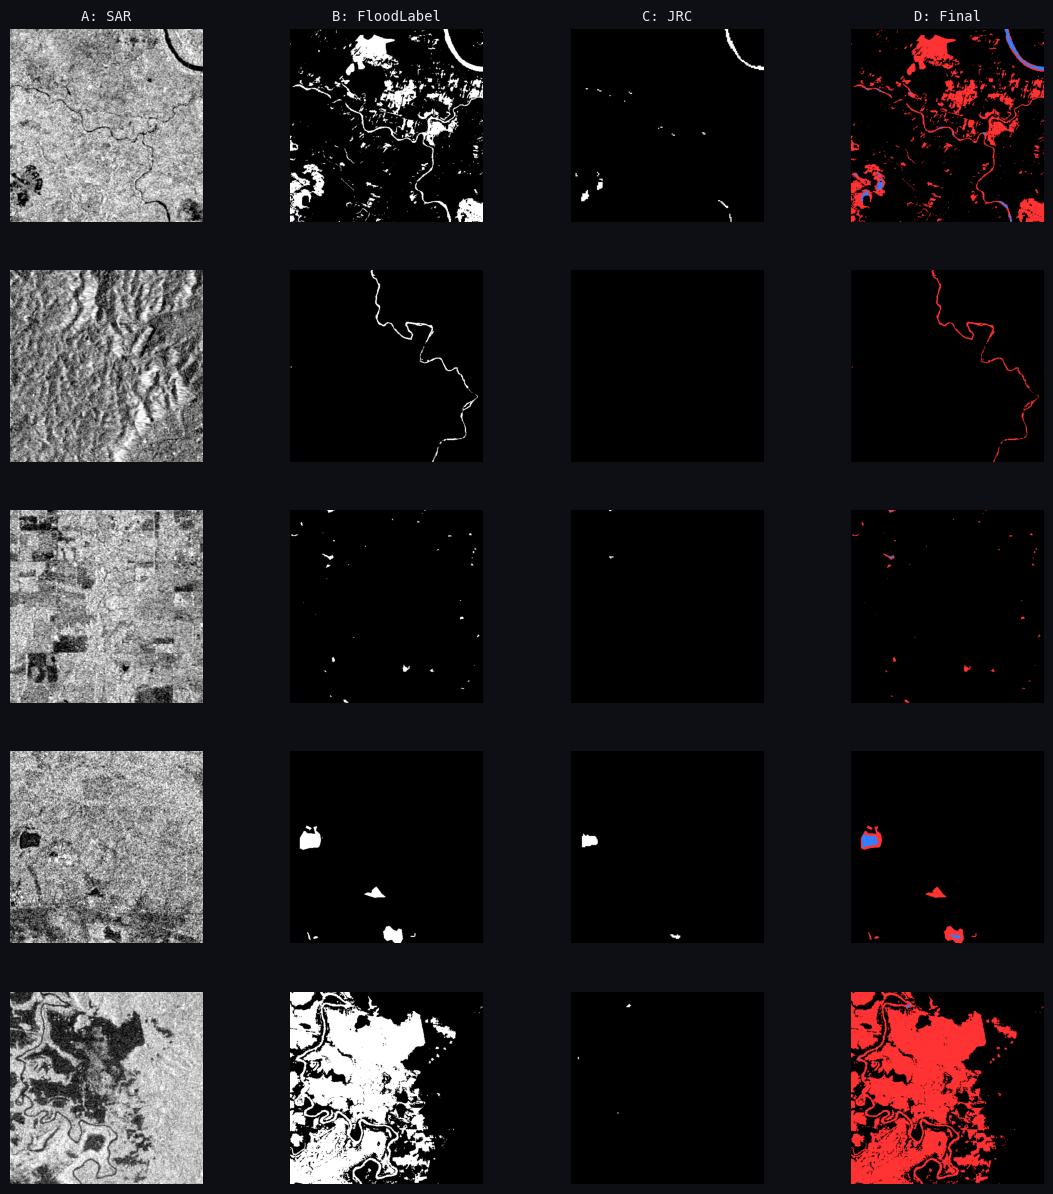

In [34]:
# visualization of what the raw and target images (flood + permanent) looks like



import random
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIG ─────────────────────────────────────────────────────────────
N_SAMPLES = 5   # 👈 change this to any number

# ── Helper ─────────────────────────────────────────────────────────────
def pct_clip(arr, lo=1, hi=99):
    p0, p1 = np.percentile(arr, [lo, hi])
    return np.clip((arr - p0) / max(p1 - p0, 1e-8), 0, 1)

def make_sar(im):
    return pct_clip(im[0])  # VV

# ── Select random samples ───────────────────────────────────────────────
indices = random.sample(range(len(df)), N_SAMPLES)

# ── Figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(14, 3 * N_SAMPLES))
plt.subplots_adjust(wspace=0.15, hspace=0.25)

# If only 1 sample, fix axis shape
if N_SAMPLES == 1:
    axes = np.expand_dims(axes, axis=0)

for row_i, idx in enumerate(indices):

    # ── Load your real data ─────────────────────────────────────────────
    label_fname = df.loc[idx, "label"].strip()
    s1_fname    = label_fname.replace("LabelHand", "S1Hand")
    jrc_fname   = label_fname.replace("LabelHand", "JRCWaterHand")

    im, lh, ljrc = load_tile(
        S1_DIR / s1_fname,
        LABEL_HAND_DIR / label_fname,
        JRC_DIR / jrc_fname
    )

    target = build_target(lh, ljrc)

    # ── Prepare ────────────────────────────────────────────────────────
    sar = make_sar(im)

    flood_mask = (lh == 1)
    jrc_mask   = (ljrc == 1)

    final_perm  = (target == 1)
    final_flood = (target == 2)

    H, W = sar.shape

    BLUE = np.array([0.2, 0.5, 1.0])
    RED  = np.array([1.0, 0.2, 0.2])

    # ── A: SAR ─────────────────────────────────────────────────────────
    axes[row_i, 0].imshow(sar, cmap="gray")

    # ── B: FloodLabel ──────────────────────────────────────────────────
    axes[row_i, 1].imshow(flood_mask, cmap="gray")

    # ── C: JRC ─────────────────────────────────────────────────────────
    axes[row_i, 2].imshow(jrc_mask, cmap="gray")

    # ── D: Final ───────────────────────────────────────────────────────
    final_vis = np.zeros((H, W, 3))
    final_vis[final_perm]  = BLUE
    final_vis[final_flood] = RED
    axes[row_i, 3].imshow(final_vis)

    # ── Labels A–D only on first row ───────────────────────────────────
    if row_i == 0:
        titles = ["A: SAR", "B: FloodLabel", "C: JRC", "D: Final"]
        for col in range(4):
            axes[row_i, col].set_title(titles[col], fontsize=10)

    # ── Clean axes ─────────────────────────────────────────────────────
    for col in range(4):
        axes[row_i, col].axis("off")

plt.show()